# Customer Churn Prediction, Risk Segmentation, and Retention Strategy

## Executive Summary

This project analyzes customer churn using the Telco Customer Churn dataset with the goal of going beyond prediction and turning model results into business action. A Logistic Regression model was selected as the final model because it delivered strong churn detection performance while remaining easy to interpret.

The analysis found that churn is concentrated among newer customers, month-to-month subscribers, fiber optic users, and customers without support-related services such as online security and tech support. Customers were then grouped into Low, Medium, High, and Critical risk segments, and revenue at risk was estimated to identify where the business is most exposed.

To make the model actionable, customer personas and targeted retention recommendations were created. This project shows that churn analysis is most valuable when it helps answer not only who is likely to leave, but also why they are at risk and what the business should do next.

## Business Goal

The goal of this project is to predict which customers are likely to churn and translate those predictions into practical business decisions. Instead of treating churn as only a machine learning problem, this analysis focuses on identifying churn drivers, segmenting customers by risk, estimating financial exposure, and recommending targeted retention actions.

The objective is to help the business prioritize which customers to focus on first and design more effective retention strategies based on customer behavior and risk profile.

### Import libraries

In [1]:
#basic data handling
import pandas as pd
import numpy as np

#vizualization
import matplotlib.pyplot as plt
import seaborn as sns

#processing and modeling
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve
)

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

In [2]:
#Load the dataset

df = pd.read_csv('Telco-Customer-Churn.csv')

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
#Check shapes and columns
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Shape: (7043, 21)

Columns:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


The dataset contains customer demographics, subscription details, billing information, and a target variable called `Churn`, which indicates whether the customer left the company.

### Data inspection

In [4]:
# Check data types and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
#Summary of missing values
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [6]:
#Check for blank strings
(df == " ").sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [7]:
# Inspect rows where TotalCharges is blank
df[df["TotalCharges"] == " "].head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No


`TotalCharges` appears to contain blank strings instead of proper missing values. This is common in the Telco churn dataset and usually occurs for customers with very low or zero tenure.

### Data Cleaning

In [8]:
# Fix TotalCharges
df["TotalCharges"] = df["TotalCharges"].replace(" ", np.nan)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"])
df["TotalCharges"] = df["TotalCharges"].fillna(0)

# Drop customerID
df = df.drop(columns=["customerID"])

# Check original Churn values before mapping
print(df["Churn"].unique())

['No' 'Yes']


In [9]:
# Remove extra spaces
df["Churn"] = df["Churn"].str.strip()

# Convert target variable to binary
df["Churn"] = df["Churn"].map({"No": 0, "Yes": 1})

# Verify
print(df["Churn"].value_counts(dropna=False))
df.head()

Churn
0    5174
1    1869
Name: count, dtype: int64


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


## Exploratory Data Analysis

### Churn Distribution

In [10]:
# Check Churn distribution
churn_counts = df["Churn"].value_counts()
print(churn_counts)
print("\nChurn rate:", df["Churn"].mean().round(3))

Churn
0    5174
1    1869
Name: count, dtype: int64

Churn rate: 0.265


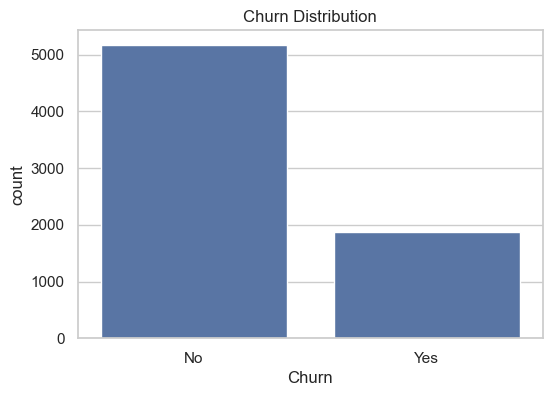

In [11]:
# Visualize churn distribution
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Churn")
plt.title("Churn Distribution")
plt.xticks([0, 1], ["No", "Yes"])
plt.show()

This helps us understand whether the target variable is balanced or imbalanced. The target variable is imbalanced, with more non-churners than churners. In churn problems, imbalance is common because fewer customers churn than stay. This is important because model evaluation should not rely only on accuracy. Metrics such as ROC-AUC, precision, and recall will be more useful later in the analysis.

### Numerical features vs churn

In [12]:
# Compare average numerical values by churn
df.groupby("Churn")[["tenure", "MonthlyCharges", "TotalCharges"]].mean()

,tenure,MonthlyCharges,TotalCharges
Churn,,,
0,37.569965,61.265124,2549.911442
1,17.979133,74.441332,1531.796094


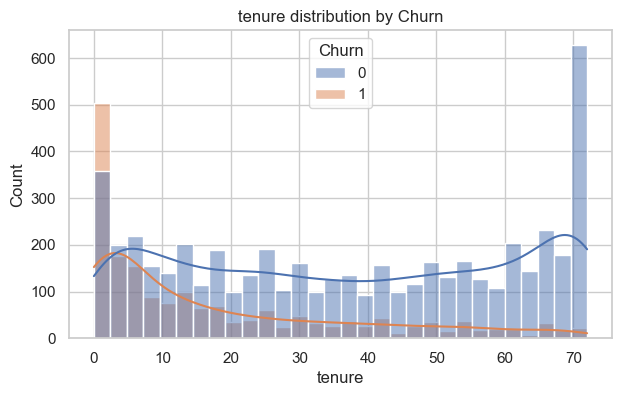

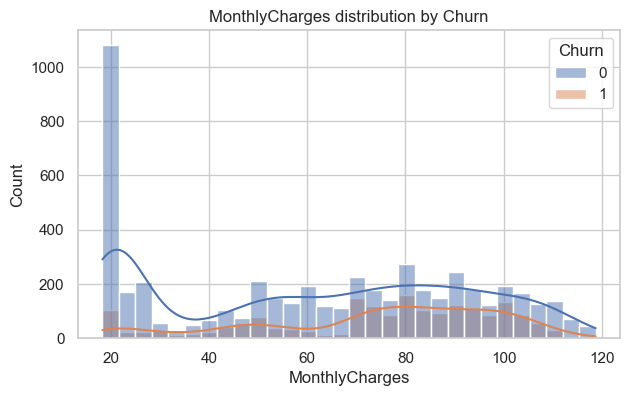

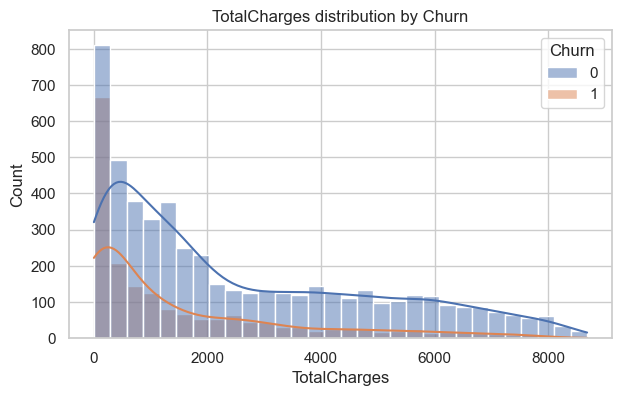

In [13]:
# Histograms for numerical variables
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

for col in num_cols:
    plt.figure(figsize=(7,4))
    sns.histplot(data=df, x=col, hue="Churn", kde=True, bins=30)
    plt.title(f"{col} distribution by Churn")
    plt.show()

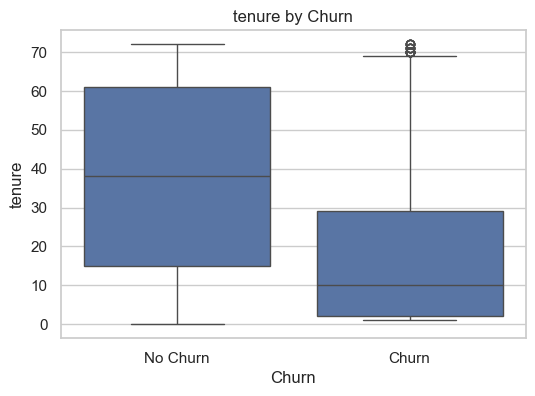

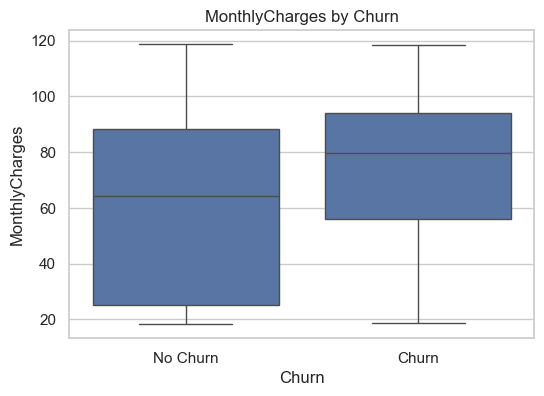

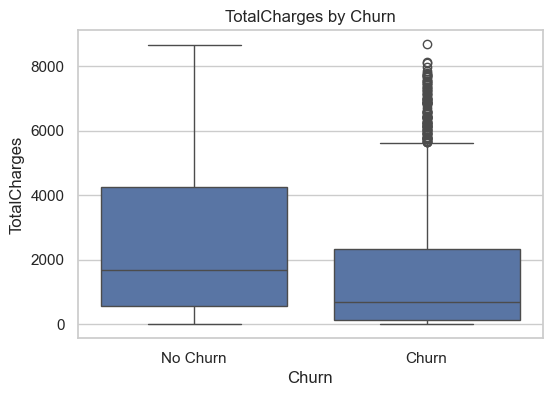

In [14]:
# Boxplots for numerical features
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(data=df, x="Churn", y=col)
    plt.title(f"{col} by Churn")
    plt.xticks([0, 1], ["No Churn", "Churn"])
    plt.show()

These plots help identify whether churned customers differ from retained customers in terms of tenure, monthly spending, and total spending.

Key early patterns to watch:
- Customers with lower tenure often churn more
- Customers with higher monthly charges tend to show higher churn risk
- Total charges can reflect a mix of tenure and spending behavior

### Categorical features vs churn

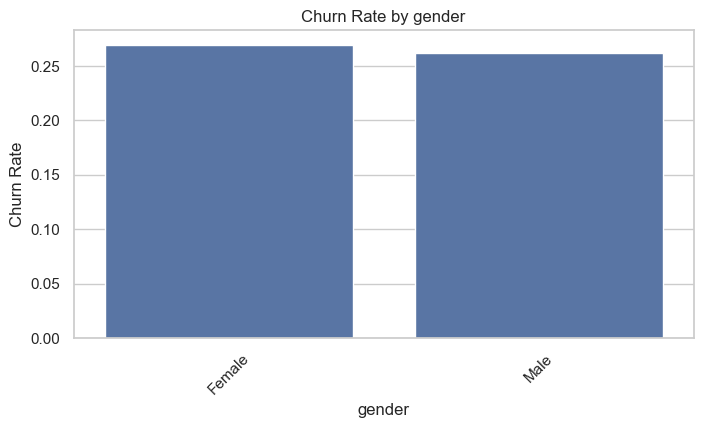

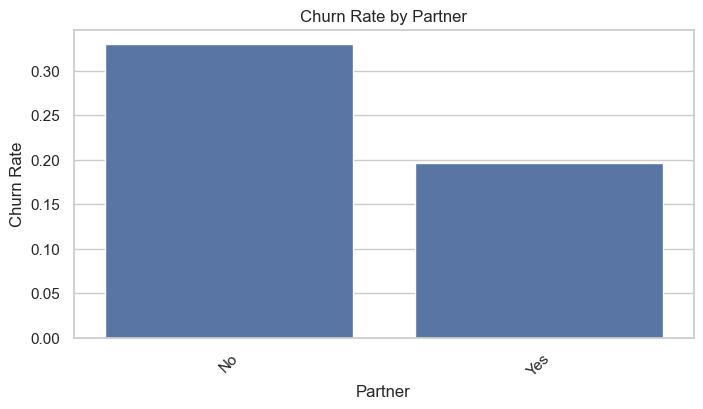

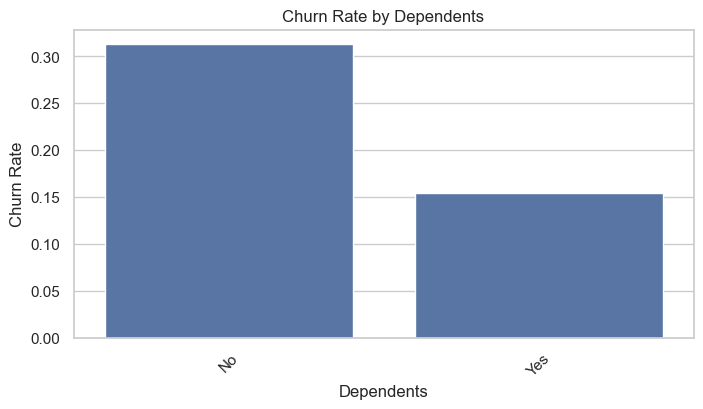

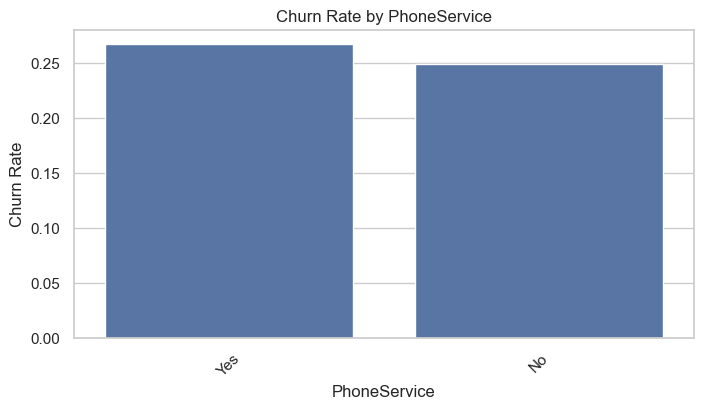

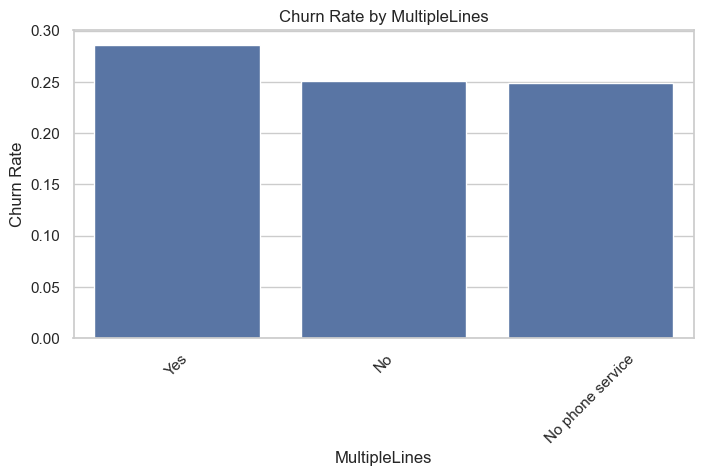

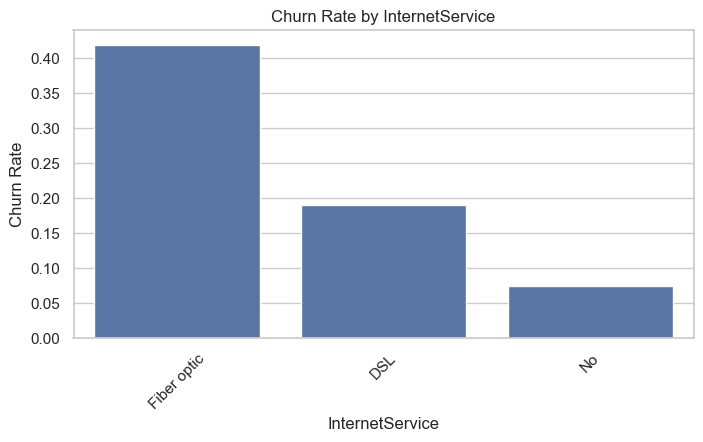

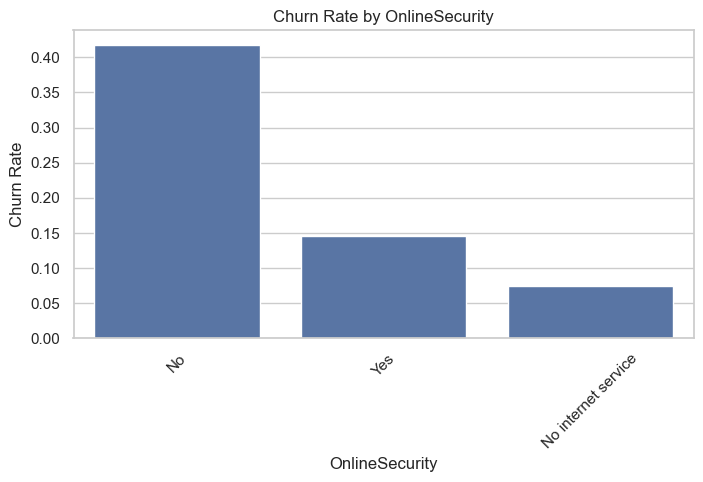

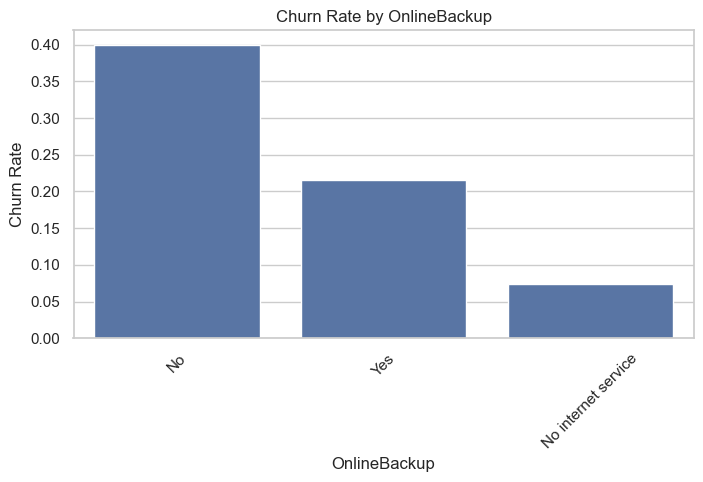

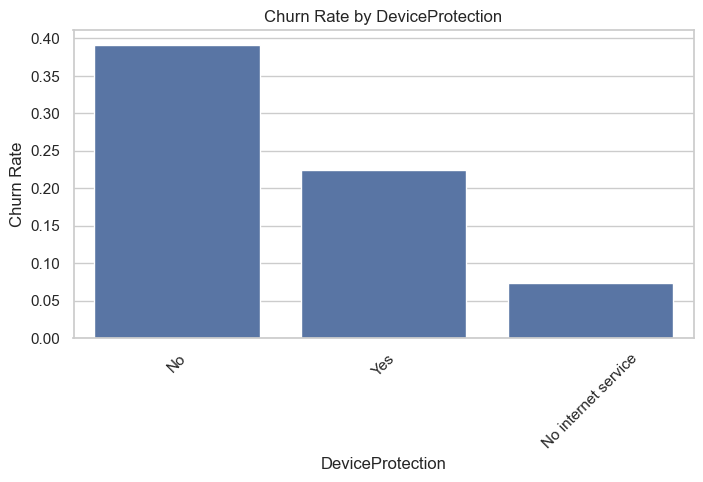

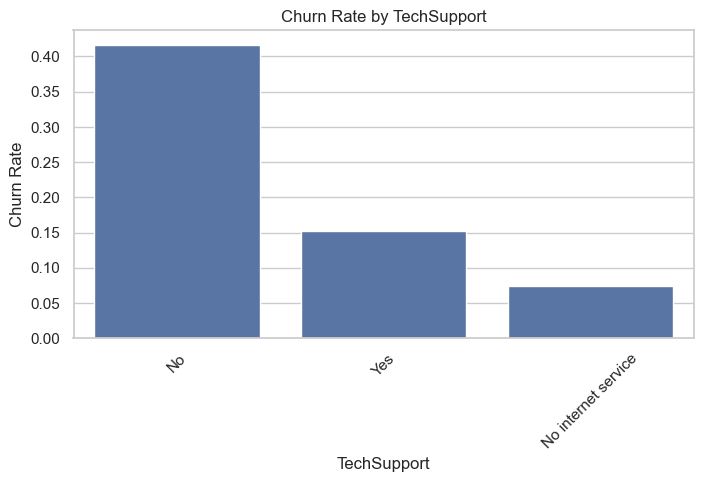

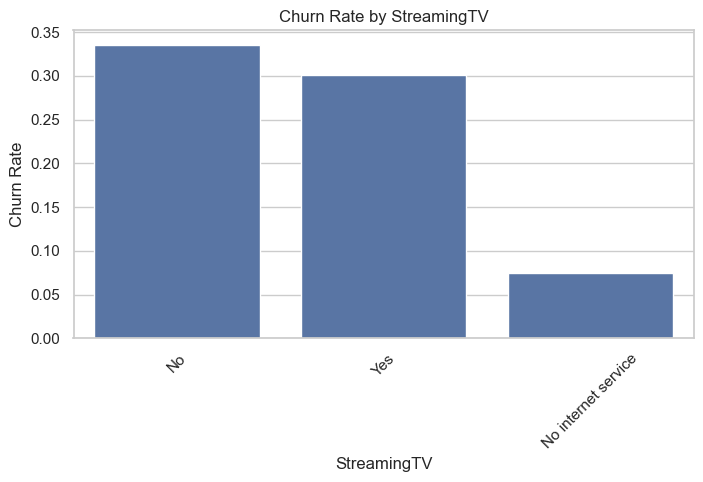

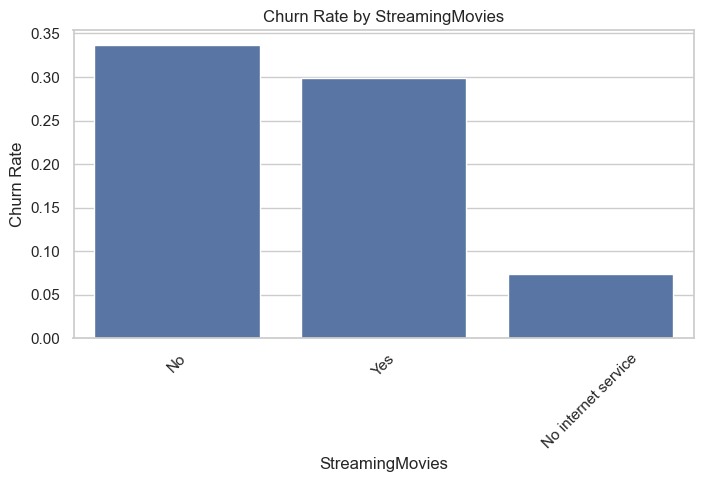

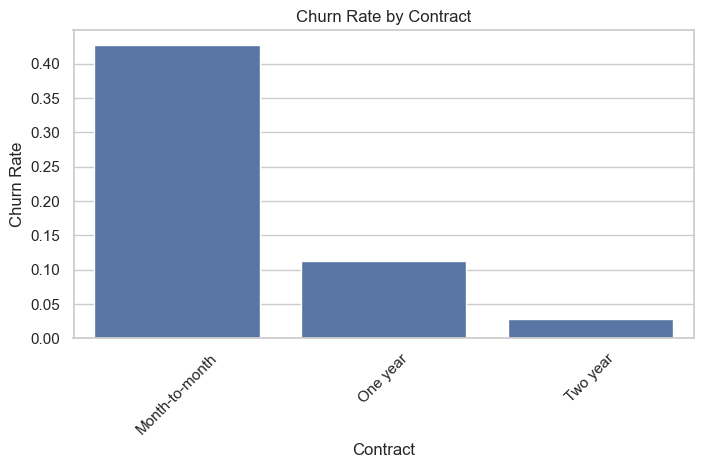

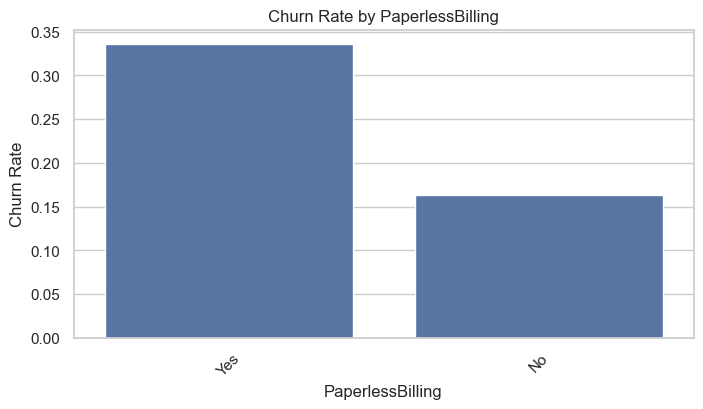

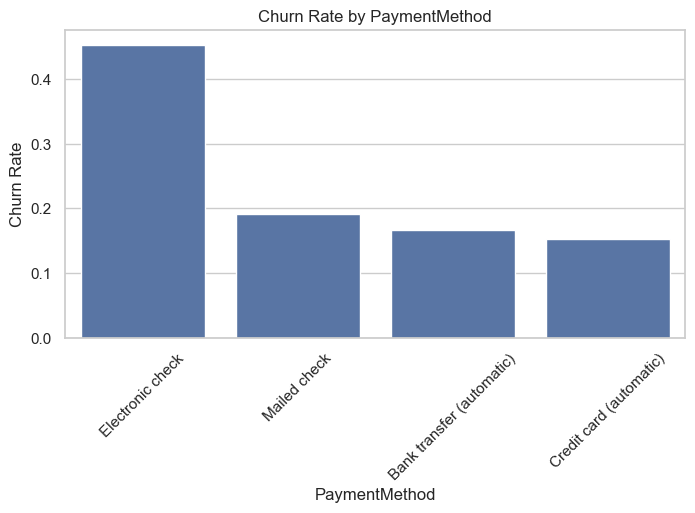

In [15]:
cat_cols = [col for col in df.columns if df[col].dtype == "object"]

for col in cat_cols:
    plt.figure(figsize=(8,4))
    churn_rate = df.groupby(col)["Churn"].mean().sort_values(ascending=False)
    sns.barplot(x=churn_rate.index, y=churn_rate.values)
    plt.title(f"Churn Rate by {col}")
    plt.xticks(rotation=45)
    plt.ylabel("Churn Rate")
    plt.show()

These charts help uncover which customer characteristics are most associated with churn. This is especially useful for designing intervention strategies later.

These charts help identify important business drivers. In this dataset, churn is often higher among:
- month-to-month customers
- fiber optic users
- customers without tech support or online security
- customers using electronic check

## Feature Engineering

In [16]:
# Create tenure bands to make interpretation easier
# this makes the customer lifecycle stage easier to interpret
df["tenure_group"] = pd.cut(
    df["tenure"],
    bins=[-1, 12, 24, 48, 72],
    labels=["0-12 months", "13-24 months", "25-48 months", "49-72 months"]
)

df["tenure_group"].value_counts()

tenure_group
49-72 months    2239
0-12 months     2186
25-48 months    1594
13-24 months    1024
Name: count, dtype: int64

In [17]:
# Count how many optional services the customer has
# this approximates product adoption depth
service_cols = [
    "OnlineSecurity", "OnlineBackup", "DeviceProtection",
    "TechSupport", "StreamingTV", "StreamingMovies"
]

df["num_services"] = 0

for col in service_cols:
    df["num_services"] += df[col].isin(["Yes"]).astype(int)

df[["num_services"]].head()

,num_services
0,1
1,2
2,2
3,3
4,0


In [18]:
# Monthly charge segments
# this helps identify spending-related risk tiers
df["monthly_charge_group"] = pd.qcut(
    df["MonthlyCharges"],
    q=4,
    labels=["Low", "Medium", "High", "Very High"]
)

df["monthly_charge_group"].value_counts()

monthly_charge_group
Medium       1766
Low          1762
Very High    1758
High         1757
Name: count, dtype: int64

In [19]:
# Check churn by engineered features
print(df.groupby("tenure_group")["Churn"].mean())
print(df.groupby("monthly_charge_group")["Churn"].mean())
print(df.groupby("num_services")["Churn"].mean())

tenure_group
0-12 months     0.474382
13-24 months    0.287109
25-48 months    0.203890
49-72 months    0.095132
Name: Churn, dtype: float64
monthly_charge_group
Low          0.112372
Medium       0.245753
High         0.375071
Very High    0.328783
Name: Churn, dtype: float64
num_services
0    0.214060
1    0.457557
2    0.358180
3    0.273703
4    0.223005
5    0.124343
6    0.052817
Name: Churn, dtype: float64


C:\Users\User\AppData\Local\Temp\ipykernel_7852\2069760274.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby("tenure_group")["Churn"].mean())
C:\Users\User\AppData\Local\Temp\ipykernel_7852\2069760274.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby("monthly_charge_group")["Churn"].mean())


## Key Insights from Engineered Features

The engineered features reveal three important churn patterns.

First, churn is heavily concentrated among newer customers. Customers in their first 12 months have the highest churn rate by a large margin, while long-tenure customers are much more stable. This suggests that early customer experience, onboarding, and first-year value realization are critical to retention.

Second, churn generally increases with monthly charges. Customers in higher billing tiers show substantially greater churn risk, which may indicate price sensitivity, poor perceived value, or mismatched plan selection.

Third, product adoption depth appears strongly related to retention. Customers with only one or two services have the highest churn rates, while customers with five or six services have very low churn. This suggests that deeper product engagement may create stickier customer relationships and lower churn risk.

Together, these findings indicate that churn is not random. It is concentrated among newer, higher-paying, and less deeply engaged customers, which creates clear opportunities for targeted retention strategies.

## Prepare data for modeling

In [20]:
# Separate features and target
X = df.drop(columns=["Churn"])
y = df["Churn"]

In [21]:
# Identify numeric and categorical columns
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'num_services']
Categorical features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'tenure_group', 'monthly_charge_group']


In [22]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (5634, 22)
X_test shape: (1409, 22)


## Build Preprocesing Pipeline

In [23]:
# Numeric variables are scaled, while categorical variables are one-hot encoded.
# Using a preprocessing pipeline keeps the workflow clean and prevents data leakage.

# Preprocessing for numeric features
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Preprocessing for categorical features
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Combine preprocessing
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

**Train Logistic Regression**

In [24]:
# Logistic Regression pipeline
log_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

# Fit the model
log_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges',
                                                   'num_services']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown...re'))]),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod',
                                                   'tenure_group',
                                                   'monthly_charge_group'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [25]:
# Predictions
y_pred = log_model.predict(X_test)
y_prob = log_model.predict_proba(X_test)[:, 1]

# Evaluation metrics
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob).round(3))

              precision    recall  f1-score   support

           0       0.91      0.71      0.80      1035
           1       0.50      0.79      0.61       374

    accuracy                           0.73      1409
   macro avg       0.70      0.75      0.70      1409
weighted avg       0.80      0.73      0.75      1409

ROC-AUC: 0.842


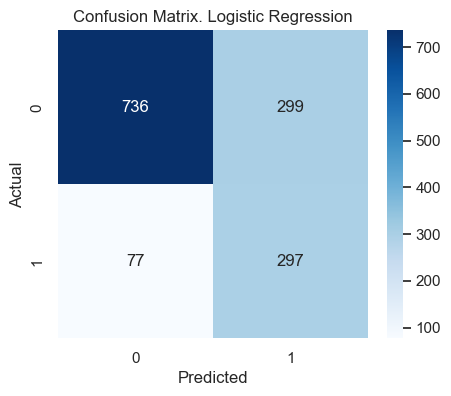

In [26]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix. Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

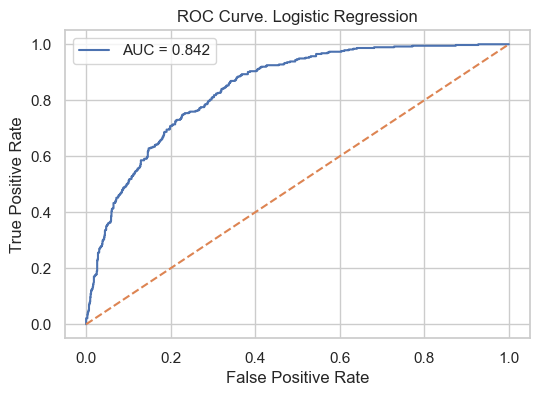

In [27]:
# ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_prob):.3f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.title("ROC Curve. Logistic Regression")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

**Train Random Forest**

In [28]:
# Random Forest pipeline
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced"
    ))
])

# Fit the model
rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges',
                                                   'num_services']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown...
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod',
                                                   'tenure_group',
                                                   'monthly_charge_group'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced',
                                        n_estimators=300, random_state=42))])

In [29]:
# Predictions
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

# Evaluation
print(classification_report(y_test, rf_pred))
print("Random Forest ROC-AUC:", roc_auc_score(y_test, rf_prob).round(3))

              precision    recall  f1-score   support

           0       0.82      0.89      0.86      1035
           1       0.61      0.47      0.53       374

    accuracy                           0.78      1409
   macro avg       0.71      0.68      0.69      1409
weighted avg       0.77      0.78      0.77      1409

Random Forest ROC-AUC: 0.82


## Predictive Modeling Approach

Two models were tested in this analysis: *Logistic Regression and Random Forest*.

Logistic Regression was chosen because it performs well on structured business data and provides clear interpretability. This is valuable in churn analysis because stakeholders often need to understand not only which customers are at risk, but also why.

Random Forest was included as a non-linear benchmark model to compare predictive performance. This helps determine whether more complex relationships in the data improve churn prediction meaningfully.

The final model selection will consider both predictive performance and business interpretability.

## Model Evaluation

The Logistic Regression model achieved a ROC-AUC of 0.842, outperforming the Random Forest model, which achieved 0.820. More importantly, Logistic Regression delivered much stronger recall on the churn class, identifying 79% of actual churners compared with only 47% for Random Forest.

This distinction matters because the business objective is not just to classify customers overall, but to detect as many at-risk customers as possible for retention intervention. In a churn setting, false negatives are typically more costly than false positives because missed churners represent lost revenue and missed retention opportunities.

For this reason, Logistic Regression was selected as the final model. In addition to stronger churn detection, it also provides clearer interpretability, making it more suitable for feature importance analysis and intervention design.

## Feature importance analysis

**Extract feature names and coefficients**

In [30]:
# Get one-hot encoded categorical feature names
ohe = log_model.named_steps["preprocessor"].named_transformers_["cat"].named_steps["onehot"]
encoded_cat_features = ohe.get_feature_names_out(categorical_features)

# Combine numeric and encoded categorical feature names
all_feature_names = numeric_features + list(encoded_cat_features)

# Extract logistic regression coefficients
coefficients = log_model.named_steps["classifier"].coef_[0]

# Create a dataframe
coef_df = pd.DataFrame({
    "Feature": all_feature_names,
    "Coefficient": coefficients
})

# Absolute value for ranking importance
coef_df["AbsCoefficient"] = coef_df["Coefficient"].abs()

# Sort by absolute coefficient
coef_df = coef_df.sort_values("AbsCoefficient", ascending=False)

coef_df.head(20)

,Feature,Coefficient,AbsCoefficient
1,tenure,-1.000940,1.000940
39,Contract_Two year,-0.850479,0.850479
17,InternetService_Fiber optic,0.725808,0.725808
37,Contract_Month-to-month,0.706183,0.706183
16,InternetService_DSL,-0.665859,0.665859
2,MonthlyCharges,-0.586635,0.586635
47,tenure_group_13-24 months,-0.373889,0.373889
49,tenure_group_49-72 months,0.327746,0.327746
40,PaperlessBilling_No,-0.264662,0.264662
23,OnlineBackup_No internet service,-0.242703,0.242703


**Show top churn drivers**

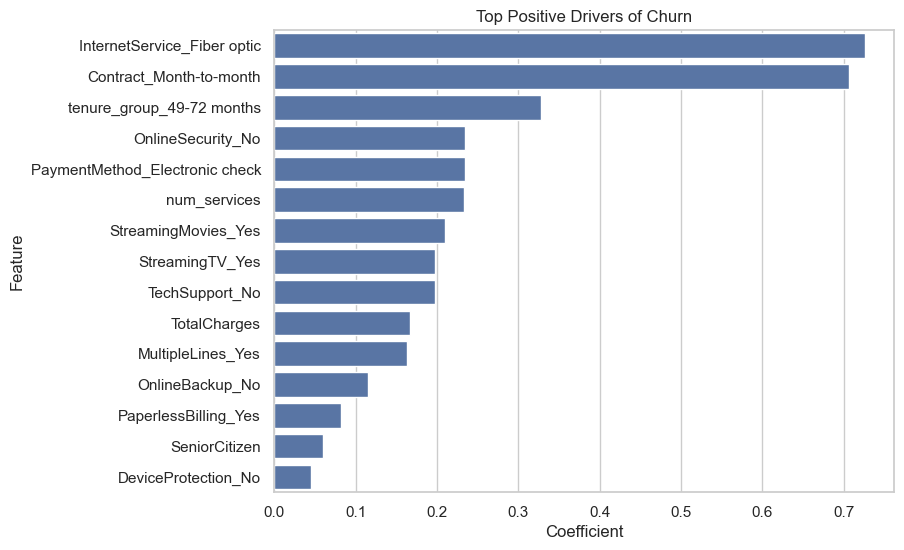

,Feature,Coefficient,AbsCoefficient
17,InternetService_Fiber optic,0.725808,0.725808
37,Contract_Month-to-month,0.706183,0.706183
49,tenure_group_49-72 months,0.327746,0.327746
19,OnlineSecurity_No,0.234608,0.234608
44,PaymentMethod_Electronic check,0.234354,0.234354
4,num_services,0.232625,0.232625
36,StreamingMovies_Yes,0.209380,0.209380
33,StreamingTV_Yes,0.197800,0.197800
28,TechSupport_No,0.197345,0.197345
3,TotalCharges,0.166645,0.166645


In [31]:
# Features that increase churn risk
top_positive = coef_df.sort_values("Coefficient", ascending=False).head(15)

plt.figure(figsize=(8,6))
sns.barplot(data=top_positive, x="Coefficient", y="Feature")
plt.title("Top Positive Drivers of Churn")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.show()

top_positive

**Show top retention drivers**

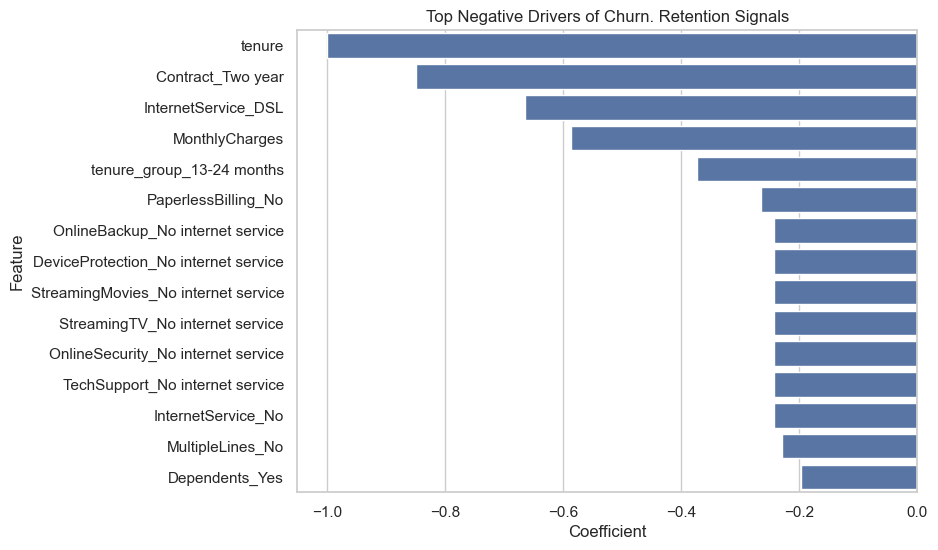

,Feature,Coefficient,AbsCoefficient
1,tenure,-1.000940,1.000940
39,Contract_Two year,-0.850479,0.850479
16,InternetService_DSL,-0.665859,0.665859
2,MonthlyCharges,-0.586635,0.586635
47,tenure_group_13-24 months,-0.373889,0.373889
40,PaperlessBilling_No,-0.264662,0.264662
23,OnlineBackup_No internet service,-0.242703,0.242703
26,DeviceProtection_No internet service,-0.242703,0.242703
35,StreamingMovies_No internet service,-0.242703,0.242703
32,StreamingTV_No internet service,-0.242703,0.242703


In [32]:
# Features that reduce churn risk
top_negative = coef_df.sort_values("Coefficient", ascending=True).head(15)

plt.figure(figsize=(8,6))
sns.barplot(data=top_negative, x="Coefficient", y="Feature")
plt.title("Top Negative Drivers of Churn. Retention Signals")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.show()

top_negative

## Feature Importance Analysis

Because Logistic Regression was selected as the final model, the coefficients can be used to understand the direction and strength of churn drivers.

Positive coefficients indicate factors associated with higher churn risk, while negative coefficients indicate factors associated with customer retention.

This step is important because it helps translate prediction into explanation. Instead of only identifying who is likely to churn, the model also helps reveal why churn risk is elevated and which business levers may be most useful for intervention.

## Interpreting Churn Drivers

The feature importance analysis highlights several strong churn signals. Customers with fiber optic internet, month-to-month contracts, no online security, no tech support, and electronic check payment methods show higher churn risk. These patterns suggest that churn is concentrated among customers with less commitment, higher service friction, and weaker support-related product adoption.

On the retention side, longer tenure and two-year contracts are among the strongest indicators of customer stability. DSL customers and customers with dependents also appear less likely to churn. Overall, the results suggest that retention is strongly linked to contract commitment, customer maturity, and support-related service adoption.

Some engineered features show mixed coefficient behavior because the model includes both raw and derived variables at the same time. For this reason, the analysis focuses primarily on the most consistent and business-interpretable drivers rather than treating every coefficient literally in isolation.

## Score all customers

In [33]:
# Score all customers using the final model which is logistic regression
df_scored = df.copy()
df_scored["churn_probability"] = log_model.predict_proba(X)[:, 1]

# Check distribution of predicted probabilities
df_scored["churn_probability"].describe()

count    7043.000000
mean        0.413417
std         0.301022
min         0.008834
25%         0.111471
50%         0.391619
75%         0.692377
max         0.953038
Name: churn_probability, dtype: float64

In [34]:
# Create risk segments
df_scored["risk_segment"] = pd.cut(
    df_scored["churn_probability"],
    bins=[0, 0.25, 0.50, 0.75, 1.0],
    labels=["Low", "Medium", "High", "Critical"]
)

df_scored["risk_segment"].value_counts()

risk_segment
Low         2737
High        1522
Medium      1404
Critical    1380
Name: count, dtype: int64

**Segment validation**

In [35]:
# This validates whether the model's predicted risk tiers align with actual churn behavior.
# A useful segmentation should show increasing actual churn rates from Low to Critical.
# Summarize actual churn by risk segment
risk_summary = df_scored.groupby("risk_segment").agg(
    customers=("Churn", "count"),
    actual_churn_rate=("Churn", "mean"),
    avg_monthly_charges=("MonthlyCharges", "mean"),
    avg_tenure=("tenure", "mean")
).reset_index()

risk_summary

C:\Users\User\AppData\Local\Temp\ipykernel_7852\3668259910.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  risk_summary = df_scored.groupby("risk_segment").agg(


,risk_segment,customers,actual_churn_rate,avg_monthly_charges,avg_tenure
0,Low,2737,0.039459,54.274224,49.607965
1,Medium,1404,0.187322,60.284687,29.454416
2,High,1522,0.367937,73.155585,24.281209
3,Critical,1380,0.679710,80.859094,10.074638


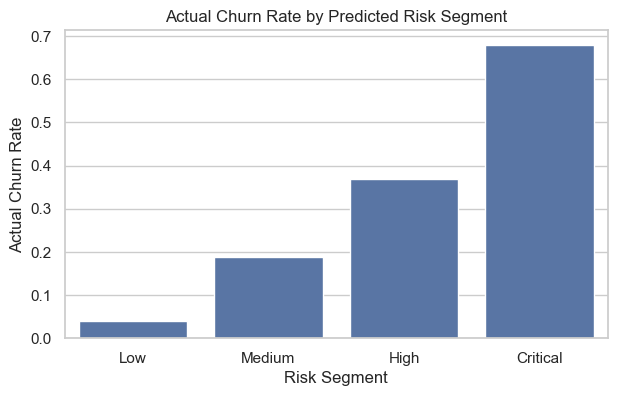

In [36]:
# Visualize actual churn rate by risk segment
plt.figure(figsize=(7,4))
sns.barplot(data=risk_summary, x="risk_segment", y="actual_churn_rate")
plt.title("Actual Churn Rate by Predicted Risk Segment")
plt.xlabel("Risk Segment")
plt.ylabel("Actual Churn Rate")
plt.show()

**Estimate revenue at risk**

In [37]:
# Estimate annualized revenue
df_scored["annual_revenue"] = df_scored["MonthlyCharges"] * 12

# Estimate expected revenue at risk
df_scored["expected_revenue_at_risk"] = (
    df_scored["annual_revenue"] * df_scored["churn_probability"]
)

In [38]:
# Revenue summary by segment
revenue_summary = df_scored.groupby("risk_segment").agg(
    customers=("Churn", "count"),
    total_annual_revenue=("annual_revenue", "sum"),
    expected_revenue_at_risk=("expected_revenue_at_risk", "sum")
).reset_index()

revenue_summary

C:\Users\User\AppData\Local\Temp\ipykernel_7852\934796895.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  revenue_summary = df_scored.groupby("risk_segment").agg(


,risk_segment,customers,total_annual_revenue,expected_revenue_at_risk
0,Low,2737,1782582.6,1.922924e+05
1,Medium,1404,1015676.4,3.804230e+05
2,High,1522,1336113.6,8.426308e+05
3,Critical,1380,1339026.6,1.132474e+06


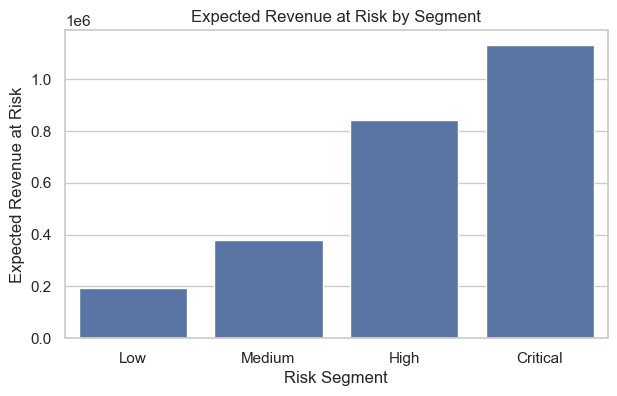

In [39]:
# Plot expected revenue at risk by segment
plt.figure(figsize=(7,4))
sns.barplot(data=revenue_summary, x="risk_segment", y="expected_revenue_at_risk")
plt.title("Expected Revenue at Risk by Segment")
plt.xlabel("Risk Segment")
plt.ylabel("Expected Revenue at Risk")
plt.show()

## Revenue at Risk

To make the churn model more actionable, predicted churn probabilities were translated into expected revenue at risk. This was estimated by multiplying each customer's annualized revenue by their predicted churn probability.

This framing helps shift the analysis from "who might churn" to "where is the business most financially exposed," which is more useful for prioritizing retention efforts.

**Persona Creation**

In [40]:
# Create business-friendly retention personas
conditions = [
    (df_scored["tenure"] <= 12) & (df_scored["Contract"] == "Month-to-month"),
    (df_scored["MonthlyCharges"] > df_scored["MonthlyCharges"].median()) & (df_scored["InternetService"] == "Fiber optic"),
    (df_scored["OnlineSecurity"] == "No") & (df_scored["TechSupport"] == "No"),
    (df_scored["PaymentMethod"] == "Electronic check")
]

choices = [
    "New customer shock",
    "Price-sensitive fiber user",
    "Unprotected / unsupported user",
    "Payment friction risk"
]

df_scored["retention_persona"] = np.select(
    conditions,
    choices,
    default="General risk"
)

In [41]:
# Persona summary
persona_summary = df_scored.groupby("retention_persona").agg(
    customers=("Churn", "count"),
    avg_churn_probability=("churn_probability", "mean"),
    actual_churn_rate=("Churn", "mean"),
    avg_monthly_charges=("MonthlyCharges", "mean")
).sort_values("avg_churn_probability", ascending=False).reset_index()

persona_summary

,retention_persona,customers,avg_churn_probability,actual_churn_rate,avg_monthly_charges
0,New customer shock,1994,0.698936,0.513541,58.217904
1,Price-sensitive fiber user,2146,0.496419,0.299627,95.869641
2,Unprotected / unsupported user,398,0.397940,0.203518,52.482789
3,Payment friction risk,321,0.240011,0.105919,52.673988
4,General risk,2184,0.099486,0.039835,44.183768


## Retention Personas

To make the model easier to use in a business setting, customers were grouped into interpretable retention personas based on common churn patterns.

These personas translate statistical risk into operational categories that a customer success or retention team could act on directly. Rather than treating all high-risk customers the same, the analysis identifies different types of churn risk, such as onboarding-related risk, pricing-related risk, support-related risk, and billing-related friction.

**Intervention logic**

In [42]:
# Recommend next-best action for each customer
def recommend_action(row):
    if row["risk_segment"] == "Low":
        return "No immediate action. Continue standard engagement."
    
    if row["retention_persona"] == "New customer shock":
        return "Launch onboarding campaign with product education and early-life check-in."
    
    if row["retention_persona"] == "Price-sensitive fiber user":
        return "Offer plan review, bundle optimization, or limited-time discount."
    
    if row["retention_persona"] == "Unprotected / unsupported user":
        return "Offer free trial of tech support or online security add-on."
    
    if row["retention_persona"] == "Payment friction risk":
        return "Encourage autopay enrollment with a small billing incentive."
    
    if row["risk_segment"] in ["High", "Critical"]:
        return "Escalate to retention team for proactive outreach and personalized offer."
    
    return "Send targeted retention communication."

df_scored["recommended_action"] = df_scored.apply(recommend_action, axis=1)

In [43]:
# Inspect highest-risk customers
df_scored[[
    "tenure", "MonthlyCharges", "Contract", "InternetService",
    "OnlineSecurity", "TechSupport", "PaymentMethod",
    "churn_probability", "risk_segment", "retention_persona",
    "recommended_action", "expected_revenue_at_risk"
]].sort_values("churn_probability", ascending=False).head(20)

,tenure,MonthlyCharges,Contract,InternetService,OnlineSecurity,TechSupport,PaymentMethod,churn_probability,risk_segment,retention_persona,recommended_action,expected_revenue_at_risk
1976,1,93.55,Month-to-month,Fiber optic,No,No,Electronic check,0.953038,Critical,New customer shock,Launch onboarding campaign with product educat...,1069.880553
3380,1,95.10,Month-to-month,Fiber optic,No,No,Electronic check,0.952940,Critical,New customer shock,Launch onboarding campaign with product educat...,1087.495348
4800,1,94.00,Month-to-month,Fiber optic,No,No,Electronic check,0.952646,Critical,New customer shock,Launch onboarding campaign with product educat...,1074.584624
3749,2,93.85,Month-to-month,Fiber optic,No,No,Electronic check,0.951260,Critical,New customer shock,Launch onboarding campaign with product educat...,1071.308632
6368,2,94.00,Month-to-month,Fiber optic,No,No,Electronic check,0.951073,Critical,New customer shock,Launch onboarding campaign with product educat...,1072.810249
2208,1,100.80,Month-to-month,Fiber optic,No,No,Electronic check,0.951042,Critical,New customer shock,Launch onboarding campaign with product educat...,1150.379888
5989,3,94.60,Month-to-month,Fiber optic,No,No,Electronic check,0.950257,Critical,New customer shock,Launch onboarding campaign with product educat...,1078.731895
1410,2,93.85,Month-to-month,Fiber optic,No,No,Electronic check,0.949899,Critical,New customer shock,Launch onboarding campaign with product educat...,1069.776473
3159,3,94.85,Month-to-month,Fiber optic,No,No,Electronic check,0.948886,Critical,New customer shock,Launch onboarding campaign with product educat...,1080.022221
997,4,94.30,Month-to-month,Fiber optic,No,No,Electronic check,0.946375,Critical,New customer shock,Launch onboarding campaign with product educat...,1070.917433


**Action summary**

In [44]:
# Count recommended actions
action_summary = df_scored["recommended_action"].value_counts().reset_index()
action_summary.columns = ["recommended_action", "count"]
action_summary

,recommended_action,count
0,No immediate action. Continue standard engagem...,2737
1,Launch onboarding campaign with product educat...,1994
2,"Offer plan review, bundle optimization, or lim...",1685
3,Offer free trial of tech support or online sec...,302
4,Send targeted retention communication.,187
5,Encourage autopay enrollment with a small bill...,129
6,Escalate to retention team for proactive outre...,9


In [45]:
# Recommended actions by risk segment
action_by_segment = pd.crosstab(df_scored["risk_segment"], df_scored["recommended_action"])
action_by_segment

recommended_action,Encourage autopay enrollment with a small billing incentive.,Escalate to retention team for proactive outreach and personalized offer.,Launch onboarding campaign with product education and early-life check-in.,No immediate action. Continue standard engagement.,Offer free trial of tech support or online security add-on.,"Offer plan review, bundle optimization, or limited-time discount.",Send targeted retention communication.
risk_segment,,,,,,,
Low,0,0,0,2737,0,0,0
Medium,101,0,425,0,178,513,187
High,28,9,554,0,117,814,0
Critical,0,0,1015,0,7,358,0


## From Prediction to Action

A churn model becomes more valuable when it can guide intervention. To support this, customers were grouped into retention personas and mapped to recommended next-best actions.

This framework transforms the model from a pure prediction tool into a decision-support tool. Instead of only identifying who is likely to churn, it helps determine what the business should do next and which customers should be prioritized for retention outreach.

## Risk Segmentation Results

The risk segmentation performed well, with actual churn rates increasing consistently from Low to Critical. Customers in the Low-risk segment had an actual churn rate of only 3.9%, while customers in the Critical segment had an actual churn rate of 68.0%. This validates that the model is successfully separating the customer base into meaningful and actionable risk tiers.

The Critical segment also stands out in two important ways. These customers have the highest average monthly charges and the lowest average tenure. This suggests that the most financially exposed customers are also those leaving early in the customer lifecycle, before long-term value can be realized.

## Revenue at Risk

Revenue-at-risk analysis shows that financial exposure is heavily concentrated in the High and Critical segments. Although Low-risk customers make up the largest share of the base, the majority of expected revenue at risk comes from customers in the top two risk tiers. This indicates that retention resources should be prioritized toward these segments rather than distributed evenly across all customers.

## Retention Personas

The persona analysis shows that churn is not driven by a single type of customer. The highest-risk persona is the "New customer shock" group, which has both the highest average churn probability and the highest actual churn rate. This suggests that onboarding and early-life customer experience are major retention challenges.

The "Price-sensitive fiber user" group is also strategically important because it combines elevated churn risk with very high monthly charges. This points to a possible pricing, bundling, or value-perception issue among premium customers.

Other personas, such as "Unprotected / unsupported user" and "Payment friction risk," represent more specific retention opportunities related to product adoption and billing experience.

Overall, the results show that churn is concentrated among newer, higher-value, and less-supported customers, which creates clear opportunities for targeted intervention.

## Recommended Intervention Strategy

Based on the model results, the company should prioritize retention efforts using targeted interventions rather than a one-size-fits-all approach.

### 1. New customer shock
Customers in this group show the highest churn risk and the highest observed churn rate. These customers should receive onboarding support, product education, and early check-ins during the first year of the customer lifecycle.

**Recommended actions:**
- 30/60/90-day onboarding campaign
- product usage education
- proactive customer success outreach
- early save offers for disengaged users

### 2. Price-sensitive fiber user
These customers have relatively high monthly charges and elevated churn risk, suggesting possible value or pricing concerns.

**Recommended actions:**
- plan optimization review
- bundle recommendations
- limited-time loyalty discount
- messaging focused on value received

### 3. Unprotected / unsupported user
Customers without online security or tech support show higher churn risk, which may indicate weaker service adoption and lower product stickiness.

**Recommended actions:**
- free trial of tech support
- free trial of online security
- support feature awareness campaign
- setup assistance for value-added services

### 4. Payment friction risk
Customers in this group may face more billing-related friction than other segments.

**Recommended actions:**
- encourage autopay enrollment
- offer a small billing incentive
- simplify billing reminders and communication

Overall, retention resources should be focused first on customers in the High and Critical risk segments, since these groups represent the greatest expected revenue at risk.

## Key Results

- Logistic Regression was selected as the final model with a ROC-AUC of 0.842
- Churn was highest among newer customers, month-to-month subscribers, fiber optic users, and customers without support-related services
- Actual churn increased from 3.9% in the Low-risk segment to 68.0% in the Critical segment
- Revenue at risk was concentrated in the High and Critical segments
- The highest-risk persona was the New customer shock group
- The strongest business opportunity is to prioritize early-life retention, pricing optimization, and support-feature adoption

## Conclusion

This project demonstrates that customer churn can be predicted effectively while also being translated into meaningful business action. The final model showed that churn is strongly linked to early customer tenure, month-to-month contracts, fiber optic service, weaker support-related adoption, and certain payment behaviors.

By combining churn prediction with risk segmentation, revenue-at-risk analysis, customer personas, and recommended interventions, the project becomes more than a modeling exercise. It becomes a decision-support tool that helps the business understand where churn risk is highest and how retention efforts should be prioritized.